# 10 - Final Model Evaluation And Evidence

**Purpose:** Collect the final proof that VisionInspect AI has a working ML pipeline.

**Expected output:** artifact status, model metrics, final inference dictionary, explainability summary, and pytest validation output.

**Platform connection:** This is the final notebook for screenshots and presentation evidence.


In [1]:
from pathlib import Path
import json
import sys
import io
import logging
import warnings
from contextlib import redirect_stderr, redirect_stdout

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BOTTLE_DIR = PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection" / "bottle"
IMAGE_SIZE = (256, 256)
LABELS = ["good", "broken_large", "broken_small", "contamination"]


def read_rgb(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def first_image(label="contamination", split="test"):
    folder = BOTTLE_DIR / split / label
    images = sorted(folder.glob("*.png"))
    if not images:
        raise FileNotFoundError(f"No images found in {folder}")
    return images[0]


def show_grid(items, cols=4, figsize=(14, 7), suptitle=None):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, item in zip(axes, items):
        title, image, cmap = item
        ax.imshow(image, cmap=cmap)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Project root:", PROJECT_ROOT)
print("MVTec bottle folder exists:", BOTTLE_DIR.exists())

import subprocess
from ml.config import MODEL_CHECKPOINT_PATH, MODEL_METADATA_PATH, MODELS_DIR
CLASSIFIER_PATH = MODELS_DIR / "defect_classifier.pkl"


def quiet_model_call(function, *args, **kwargs):
    """Run noisy model code while keeping notebook outputs presentation-clean."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        logging.disable(logging.CRITICAL)
        try:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                return function(*args, **kwargs)
        finally:
            logging.disable(logging.NOTSET)


Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai-github
MVTec bottle folder exists: True


## End-To-End Inspection Workflow

The diagram below summarizes how a product image moves through the AI inspection pipeline and becomes a quality-control decision.


,step,stage,output
0,1,Image Input,Product image
1,2,Preprocessing,Normalized image
2,3,PaDiM Detection,Anomaly map + score
3,4,Classification,Defect type + confidence
4,5,Severity,Risk score
5,6,QA Decision,Pass / Review / Fail
6,7,Backend Output,Inspection JSON


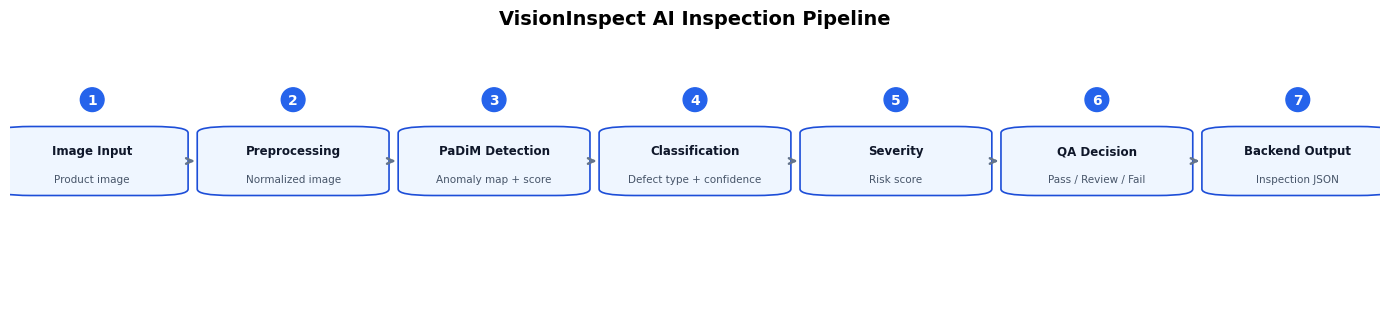

In [2]:
from matplotlib.patches import FancyBboxPatch

workflow_df = pd.DataFrame([
    {"step": 1, "stage": "Image Input", "output": "Product image"},
    {"step": 2, "stage": "Preprocessing", "output": "Normalized image"},
    {"step": 3, "stage": "PaDiM Detection", "output": "Anomaly map + score"},
    {"step": 4, "stage": "Classification", "output": "Defect type + confidence"},
    {"step": 5, "stage": "Severity", "output": "Risk score"},
    {"step": 6, "stage": "QA Decision", "output": "Pass / Review / Fail"},
    {"step": 7, "stage": "Backend Output", "output": "Inspection JSON"},
])
display(workflow_df)

fig, ax = plt.subplots(figsize=(14, 3.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

xs = np.linspace(0.06, 0.94, len(workflow_df))
for idx, (_, row) in enumerate(workflow_df.iterrows()):
    x = xs[idx]
    box = FancyBboxPatch(
        (x - 0.055, 0.42), 0.11, 0.24,
        boxstyle="round,pad=0.015,rounding_size=0.025",
        linewidth=1.2,
        edgecolor="#1d4ed8",
        facecolor="#eff6ff",
    )
    ax.add_patch(box)
    ax.text(x, 0.58, row["stage"], ha="center", va="center", fontsize=8.5, fontweight="bold", color="#0f172a")
    ax.text(x, 0.47, row["output"], ha="center", va="center", fontsize=7.5, color="#475569")
    ax.text(x, 0.78, f"{row['step']}", ha="center", va="center", fontsize=10, fontweight="bold", color="white",
            bbox=dict(boxstyle="circle,pad=0.35", facecolor="#2563eb", edgecolor="#2563eb"))
    if idx < len(workflow_df) - 1:
        ax.annotate("", xy=(xs[idx + 1] - 0.07, 0.54), xytext=(x + 0.07, 0.54), arrowprops=dict(arrowstyle="->", lw=1.8, color="#64748b"))

ax.set_title("VisionInspect AI Inspection Pipeline", fontsize=14, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()


## Model Artifact Status


In [3]:
artifact_paths = [
    PROJECT_ROOT / "models" / "defect_classifier.pkl",
    PROJECT_ROOT / "models" / "model_metadata.json",
    PROJECT_ROOT / "models" / "inference" / "normal_reference.png",
    PROJECT_ROOT / "models" / "checkpoints" / "padim_mvtec_bottle_v1.ckpt",
]
display(pd.DataFrame([{"artifact": path.name, "path": str(path), "exists": path.exists(), "size_mb": round(path.stat().st_size / (1024 * 1024), 2) if path.exists() else None} for path in artifact_paths]))


,artifact,path,exists,size_mb
0,defect_classifier.pkl,C:\Users\HP\Desktop\springboard\visioninspect-...,True,0.03
1,model_metadata.json,C:\Users\HP\Desktop\springboard\visioninspect-...,True,0.00
2,normal_reference.png,C:\Users\HP\Desktop\springboard\visioninspect-...,True,0.03
3,padim_mvtec_bottle_v1.ckpt,C:\Users\HP\Desktop\springboard\visioninspect-...,True,168.49


## Model Metrics And Comparison


,metric,value
0,image_AUROC,0.998413
1,image_F1Score,0.983871
2,pixel_AUROC,0.982058
3,pixel_F1Score,0.713580


,model,task,main_strength
0,OpenCV baseline,explainable fallback anomaly scoring,fast and interpretable
1,PaDiM,professional anomaly detection/localization,image and pixel-level anomaly scoring
2,ResNet18 + classifier,defect type classification,category and confidence output


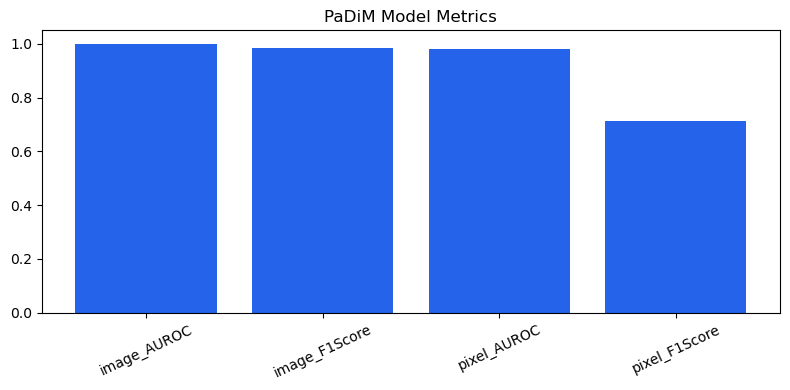

In [4]:
metadata = json.loads(MODEL_METADATA_PATH.read_text(encoding="utf-8")) if MODEL_METADATA_PATH.exists() else {"metrics": {}}
padim_df = pd.DataFrame([{"metric": key, "value": value} for key, value in metadata.get("metrics", {}).items()])
display(padim_df)
display(pd.DataFrame([
    {"model": "OpenCV baseline", "task": "explainable fallback anomaly scoring", "main_strength": "fast and interpretable"},
    {"model": "PaDiM", "task": "professional anomaly detection/localization", "main_strength": "image and pixel-level anomaly scoring"},
    {"model": "ResNet18 + classifier", "task": "defect type classification", "main_strength": "category and confidence output"},
]))
if not padim_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(padim_df["metric"], padim_df["value"], color="#2563eb")
    ax.set_ylim(0, 1.05)
    ax.set_title("PaDiM Model Metrics")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()


## Final Backend-Ready Prediction Dictionary


{
  "prediction": "Defective",
  "defect_type": "contamination",
  "confidence": 0.9996,
  "anomaly_score": 0.679,
  "defect_area_ratio": 0.097,
  "heatmap_path": "inline:notebook_heatmap",
  "severity_score": 83.24,
  "severity_level": "Critical",
  "pass_fail": "Fail",
  "model_used": "padim:v1 (padim)"
}


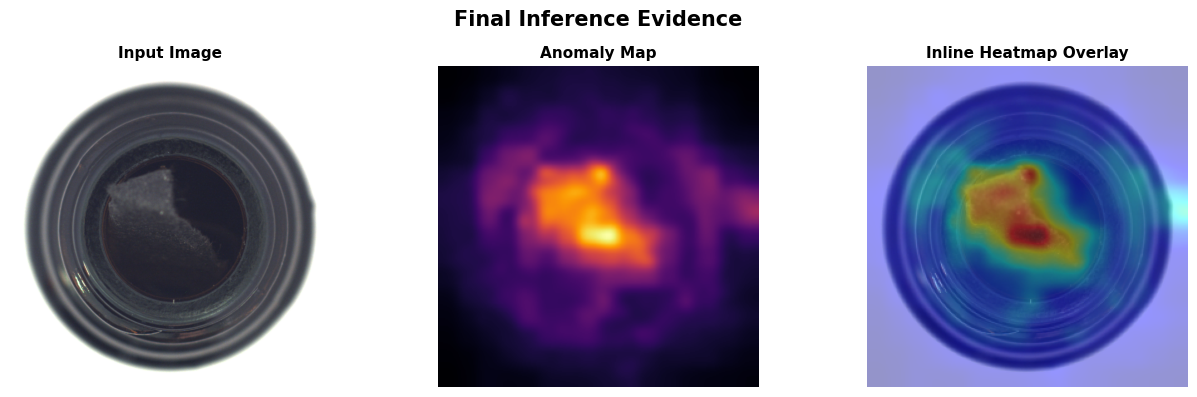

In [5]:
if str(PROJECT_ROOT / "backend") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "backend"))
from app.services.padim_service import predict_with_padim
from ml.defect_classifier import classify_defect_type
from ml.inference import compute_defect_geometry
from ml.severity import calculate_severity_from_prediction

image_path = first_image("contamination", "test")
image_rgb = read_rgb(image_path)
anomaly = quiet_model_call(predict_with_padim, image_path, MODEL_CHECKPOINT_PATH)
classification = quiet_model_call(classify_defect_type, image_path, CLASSIFIER_PATH)
if not anomaly["is_defective"]:
    classification = {"defect_type": "good", "confidence": anomaly["detection_confidence"], "class_probabilities": {"good": anomaly["detection_confidence"]}}
elif classification["defect_type"] == "good":
    classification["defect_type"] = "unknown_defect"
    classification["confidence"] = max(float(classification["confidence"]), float(anomaly["detection_confidence"]))
geometry = compute_defect_geometry(anomaly["pred_mask"], classification["defect_type"])
severity = calculate_severity_from_prediction(classification["defect_type"], classification["confidence"], geometry["area_ratio"], geometry["is_critical_location"], geometry["defect_center_y_ratio"])

raw_prediction = {
    "prediction": "Defective" if anomaly["is_defective"] else "Good",
    "defect_type": classification["defect_type"],
    "confidence": round(float(classification["confidence"]), 4),
    "anomaly_score": round(float(anomaly["anomaly_score"]), 4),
    "defect_area_ratio": round(float(geometry["area_ratio"]), 4),
    "heatmap_path": "inline:notebook_heatmap",
    "severity_score": severity["severity_score"],
    "severity_level": severity["severity_level"],
    "pass_fail": severity["pass_fail"],
    "model_used": f"{metadata.get('model_name', 'model')}:{metadata.get('model_version', 'local')} ({anomaly['engine']})",
}
print(json.dumps(raw_prediction, indent=2))

normalized = cv2.normalize(anomaly["anomaly_map"], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
heatmap_rgb = cv2.cvtColor(cv2.applyColorMap(normalized, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
base = cv2.resize(image_rgb, (heatmap_rgb.shape[1], heatmap_rgb.shape[0]), interpolation=cv2.INTER_AREA)
overlay = cv2.addWeighted(base, 0.58, heatmap_rgb, 0.42, 0)
show_grid([("Input Image", image_rgb, None), ("Anomaly Map", anomaly["anomaly_map"], "inferno"), ("Inline Heatmap Overlay", overlay, None)], cols=3, figsize=(13, 4), suptitle="Final Inference Evidence")


## Hero Inspection Result

This is the single most important screenshot: one real product image, the AI decision, severity, and business action in one place.


,field,value
0,Product image,000.png
1,AI prediction,Defective
2,Defect type,contamination
3,Confidence,99.96%
4,Anomaly score,0.679
5,Defect area,9.70%
6,Severity,Critical
7,Final decision,Fail
8,Model used,padim:v1 (padim)


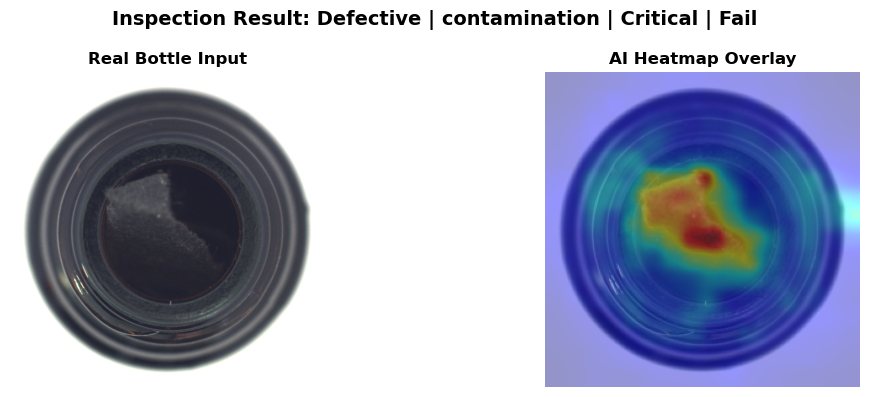

In [6]:
hero_summary = pd.DataFrame([
    {"field": "Product image", "value": image_path.name},
    {"field": "AI prediction", "value": raw_prediction["prediction"]},
    {"field": "Defect type", "value": raw_prediction["defect_type"]},
    {"field": "Confidence", "value": f"{raw_prediction['confidence'] * 100:.2f}%"},
    {"field": "Anomaly score", "value": raw_prediction["anomaly_score"]},
    {"field": "Defect area", "value": f"{raw_prediction['defect_area_ratio'] * 100:.2f}%"},
    {"field": "Severity", "value": raw_prediction["severity_level"]},
    {"field": "Final decision", "value": raw_prediction["pass_fail"]},
    {"field": "Model used", "value": raw_prediction["model_used"]},
])
display(hero_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(image_rgb)
axes[0].set_title("Real Bottle Input", fontsize=12, fontweight="bold")
axes[0].axis("off")
axes[1].imshow(overlay)
axes[1].set_title("AI Heatmap Overlay", fontsize=12, fontweight="bold")
axes[1].axis("off")
fig.suptitle(f"Inspection Result: {raw_prediction['prediction']} | {raw_prediction['defect_type']} | {raw_prediction['severity_level']} | {raw_prediction['pass_fail']}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## Ground Truth vs Predicted Localization

MVTec provides defect masks. Comparing the predicted mask against the ground truth makes the localization evidence much stronger than showing a heatmap alone.


,ground_truth_area_percent,predicted_area_percent,overlap_iou,dice_score,ground_truth_coverage
0,7.25,9.7,0.7328,0.8458,0.9889


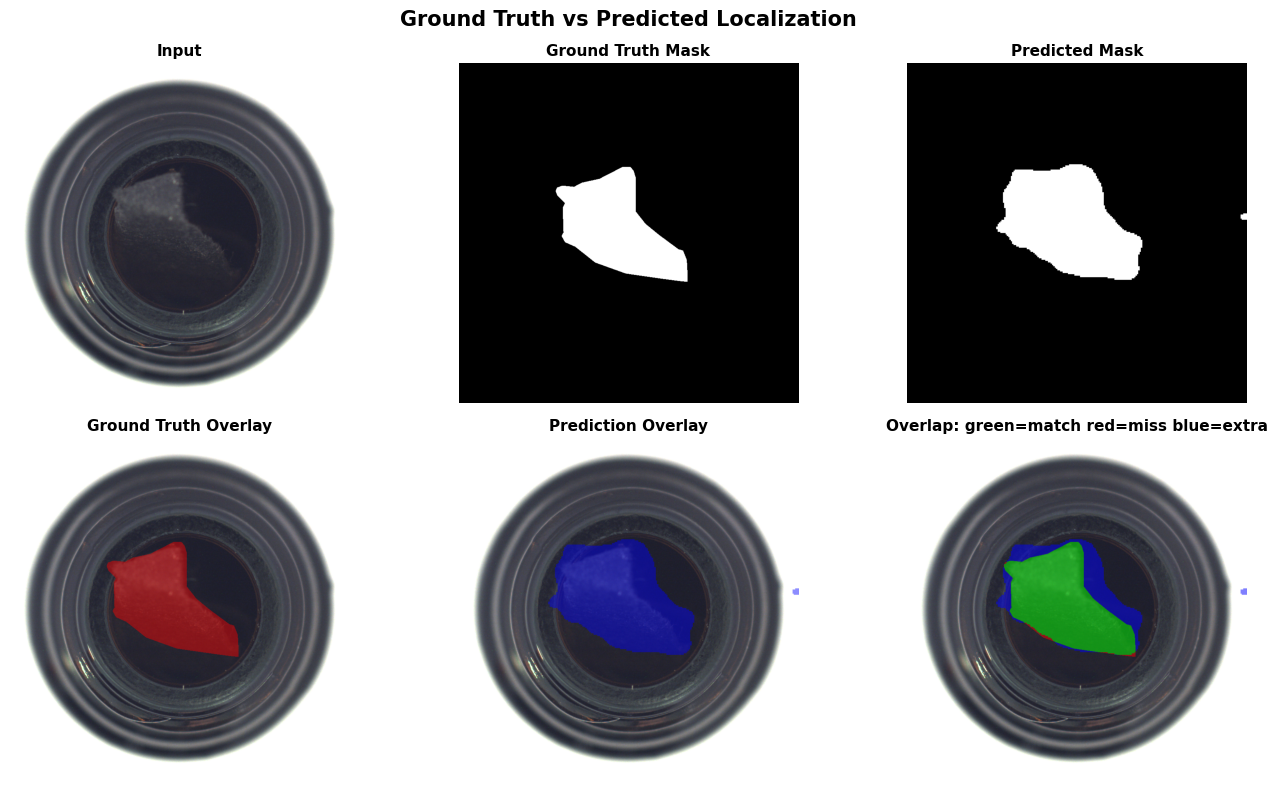

In [7]:
mask_path = BOTTLE_DIR / "ground_truth" / raw_prediction["defect_type"] / f"{image_path.stem}_mask.png"
ground_truth_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
if ground_truth_mask is None:
    raise FileNotFoundError(f"Ground truth mask not found: {mask_path}")

gt_bool = ground_truth_mask > 0
pred_mask = np.asarray(anomaly["pred_mask"]).astype(bool)
if pred_mask.shape != gt_bool.shape:
    pred_mask = cv2.resize(pred_mask.astype(np.uint8), (gt_bool.shape[1], gt_bool.shape[0]), interpolation=cv2.INTER_NEAREST).astype(bool)

intersection = np.logical_and(gt_bool, pred_mask).sum()
union = np.logical_or(gt_bool, pred_mask).sum()
pred_sum = pred_mask.sum()
gt_sum = gt_bool.sum()
iou = float(intersection / union) if union else 0.0
dice = float((2 * intersection) / (pred_sum + gt_sum)) if (pred_sum + gt_sum) else 0.0
coverage = float(intersection / gt_sum) if gt_sum else 0.0

localization_df = pd.DataFrame([{
    "ground_truth_area_percent": round(float(gt_bool.mean() * 100), 2),
    "predicted_area_percent": round(float(pred_mask.mean() * 100), 2),
    "overlap_iou": round(iou, 4),
    "dice_score": round(dice, 4),
    "ground_truth_coverage": round(coverage, 4),
}])
display(localization_df)

rgb_resized = cv2.resize(image_rgb, (gt_bool.shape[1], gt_bool.shape[0]), interpolation=cv2.INTER_AREA)
gt_overlay = rgb_resized.copy()
gt_red = np.zeros_like(gt_overlay)
gt_red[:, :, 0] = 255
gt_overlay = np.where(gt_bool[..., None], (0.55 * gt_overlay + 0.45 * gt_red).astype(np.uint8), gt_overlay)

pred_overlay = rgb_resized.copy()
pred_blue = np.zeros_like(pred_overlay)
pred_blue[:, :, 2] = 255
pred_overlay = np.where(pred_mask[..., None], (0.55 * pred_overlay + 0.45 * pred_blue).astype(np.uint8), pred_overlay)

overlap_rgb = rgb_resized.copy()
colors = np.zeros_like(overlap_rgb)
colors[np.logical_and(gt_bool, pred_mask)] = [0, 255, 0]
colors[np.logical_and(gt_bool, ~pred_mask)] = [255, 0, 0]
colors[np.logical_and(~gt_bool, pred_mask)] = [0, 0, 255]
mask_any = np.logical_or(gt_bool, pred_mask)
overlap_rgb = np.where(mask_any[..., None], (0.50 * overlap_rgb + 0.50 * colors).astype(np.uint8), overlap_rgb)

show_grid([
    ("Input", rgb_resized, None),
    ("Ground Truth Mask", ground_truth_mask, "gray"),
    ("Predicted Mask", pred_mask, "gray"),
    ("Ground Truth Overlay", gt_overlay, None),
    ("Prediction Overlay", pred_overlay, None),
    ("Overlap: green=match red=miss blue=extra", overlap_rgb, None),
], cols=3, figsize=(14, 8), suptitle="Ground Truth vs Predicted Localization")


## Inference Latency Check

Latency shows whether the model can realistically support an inspection workflow. This single-image timing includes PaDiM inference only, not frontend upload or database storage.


In [8]:
import time

latency_runs = []
for run_id in range(3):
    start = time.perf_counter()
    _ = quiet_model_call(predict_with_padim, image_path, MODEL_CHECKPOINT_PATH)
    latency_runs.append(time.perf_counter() - start)

latency_df = pd.DataFrame([{
    "run": idx + 1,
    "latency_seconds": round(value, 3),
} for idx, value in enumerate(latency_runs)])
display(latency_df)

display(pd.DataFrame([{
    "mean_latency_seconds": round(float(np.mean(latency_runs)), 3),
    "min_latency_seconds": round(float(np.min(latency_runs)), 3),
    "max_latency_seconds": round(float(np.max(latency_runs)), 3),
    "interpretation": "single-image model inference timing on local machine",
}]))


,run,latency_seconds
0,1,0.399
1,2,0.314
2,3,0.295


,mean_latency_seconds,min_latency_seconds,max_latency_seconds,interpretation
0,0.336,0.295,0.399,single-image model inference timing on local m...


## Explainability Summary


In [9]:
display(pd.DataFrame([{
    "engine": raw_prediction["model_used"],
    "decision_threshold": round(float(anomaly.get("decision_threshold", 0)), 4),
    "anomaly_score": raw_prediction["anomaly_score"],
    "defect_area_percent": round(raw_prediction["defect_area_ratio"] * 100, 2),
    "critical_location": geometry["is_critical_location"],
    "severity_basis": severity["components"],
    "why_failed": "anomaly score exceeded threshold and severity requires QA action" if raw_prediction["pass_fail"] != "Pass" else "severity stayed within pass range",
}]))


,engine,decision_threshold,anomaly_score,defect_area_percent,critical_location,severity_basis,why_failed
0,padim:v1 (padim),0.5,0.679,9.7,True,"{'size_score': 90.0, 'location_score': 90.0, '...",anomaly score exceeded threshold and severity ...


## Pytest Validation Output


In [10]:
completed = subprocess.run([sys.executable, "-m", "pytest", "tests"], cwd=PROJECT_ROOT, text=True, capture_output=True, check=False)
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
print("pytest_exit_code:", completed.returncode)


============================= test session starts =============================
platform win32 -- Python 3.13.5, pytest-9.1.1, pluggy-1.5.0
rootdir: C:\Users\HP\Desktop\springboard\visioninspect-ai-github
configfile: pyproject.toml
plugins: anyio-4.7.0, langsmith-0.8.5
collected 22 items

tests\test_api.py ....                                                   [ 18%]
tests\test_auth.py ..                                                    [ 27%]
tests\test_baseline_detector.py ...                                      [ 40%]
tests\test_camera_samples.py .                                           [ 45%]
tests\test_classifier_artifact.py .                                      [ 50%]
tests\test_dataset_loader.py .                                           [ 54%]
tests\test_heatmap.py ..                                                 [ 63%]
tests\test_kfold_validation.py ..                                        [ 72%]
tests\test_prediction.py .                                            

## Limitations And Future Improvements

- Lighting and camera angle can affect baseline detection, so factory deployment should use controlled image acquisition.
- The classifier depends on available labeled defect categories; new defect types need new examples.
- PaDiM needs a valid trained checkpoint and suitable GPU/CPU hosting for fast live inference.
- Real factory integration would need camera calibration, PLC/MES integration, production line metadata, and monitoring.
- Thresholds should be calibrated using validation data before real production deployment.


## Final Inspection Summary

VisionInspect AI processed a real MVTec bottle image through anomaly detection, defect classification, localization assessment, severity scoring, and quality-decision generation.

The notebook evidence includes the input image, anomaly map, heatmap overlay, ground-truth comparison, localization metrics, prediction dictionary, severity rationale, inference latency, and automated test results.


## Final ML Pipeline Conclusion

- Real MVTec bottle data is loaded, validated, visualized, and inspected.
- Preprocessing converts raw images into cleaner model-ready inputs.
- Baseline detection provides explainable anomaly scoring and heatmaps.
- PaDiM provides professional anomaly localization metrics and live inference.
- The classifier adds defect type and confidence.
- Severity scoring converts AI output into QA decisions.
- The final dictionary is backend-ready and tests validate core functions.
